# Notebook 05: K-Fold Cross-Validation
## Multi-Source Binary Classification of Diabetic Retinopathy

**Purpose:** 5-fold stratified cross-validation for robust performance estimation.

**Dataset:** APTOS 2019 only

**Prerequisites:** Run `Notebook_02_Splitting_DataLoader.ipynb` first.

**Outputs:**
- Per-fold saved models in `models/kfold/`
- `models/kfold/kfold_results.csv` — per-fold metrics
- `models/kfold/kfold_results.png` — visualization
- K-Fold ensemble evaluation on held-out test set

---

In [14]:
# ==================== IMPORTS & ENVIRONMENT ====================
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import time
import warnings
import copy
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, cohen_kappa_score, matthews_corrcoef
)

print(f'PyTorch: {torch.__version__}')
print(f'timm:    {timm.__version__}')

PyTorch: 2.7.1
timm:    1.0.24


In [16]:
# ==================== CONFIGURATION ====================

class CFG:
    # Paths
    data_dir    = '.'
    splits_dir  = 'splits_aptos'
    output_dir  = 'models/kfold'

    # Model
    model_name  = 'efficientnet_b3'
    pretrained  = True
    num_classes = 1                              # binary → single sigmoid output

    # Training (M1 Pro optimized)
    img_size      = 384
    batch_size    = 8
    accumulation  = 2                            # effective batch = 16
    epochs        = 30
    lr            = 3e-4
    weight_decay  = 1e-5
    patience      = 7                            # early stopping

    # K-Fold
    n_folds         = 5
    stratify_column = 'dr_grade'                 # stratify on 5-class grade
    label_column    = 'binary_label'             # binary target
    path_column     = 'preprocessed_path'        # relative image path

    seed          = 42

    # DataLoader (M1 Pro)
    num_workers   = 0
    pin_memory    = False

    # Augmentation
    use_mixup     = True
    mixup_alpha   = 0.4

    # TTA
    tta_times     = 8

os.makedirs(CFG.output_dir, exist_ok=True)

# Reproducibility
def seed_everything(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(CFG.seed)

# Device
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print('Using: Apple M1 Pro GPU (MPS)')
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Using: CUDA ({torch.cuda.get_device_name(0)})')
else:
    device = torch.device('cpu')
    print('Using: CPU')

print(f'\nModel:         {CFG.model_name}')
print(f'Image size:    {CFG.img_size}x{CFG.img_size}')
print(f'Effective BS:  {CFG.batch_size} x {CFG.accumulation} = {CFG.batch_size * CFG.accumulation}')
print(f'K-Fold:        {CFG.n_folds}-fold (stratified on {CFG.stratify_column})')
print(f'Output:        {CFG.output_dir}')

Using: Apple M1 Pro GPU (MPS)

Model:         efficientnet_b3
Image size:    384x384
Effective BS:  8 x 2 = 16
K-Fold:        5-fold (stratified on dr_grade)
Output:        models/kfold


---
## 1. Load Splits & Components

In [18]:
# ==================== LOAD SAVED SPLITS ====================
train_df = pd.read_csv(os.path.join(CFG.data_dir, CFG.splits_dir, 'train_split.csv'))
val_df   = pd.read_csv(os.path.join(CFG.data_dir, CFG.splits_dir, 'val_split.csv'))
test_df  = pd.read_csv(os.path.join(CFG.data_dir, CFG.splits_dir, 'test_split.csv'))

print(f'Loaded splits from {CFG.splits_dir}/')
print(f'  Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'  Train DR ratio: {train_df[CFG.label_column].mean():.3f}')
print(f'  Val   DR ratio: {val_df[CFG.label_column].mean():.3f}')
print(f'  Test  DR ratio: {test_df[CFG.label_column].mean():.3f}')

# Verify DR grade distribution
print(f'\nDR grade distribution (Train):')
print(train_df['dr_grade'].value_counts().sort_index().to_string())

Loaded splits from splits_aptos/
  Train: 2473 | Val: 530 | Test: 531
  Train DR ratio: 0.491
  Val   DR ratio: 0.491
  Test  DR ratio: 0.492

DR grade distribution (Train):
dr_grade
0    1258
1     228
2     665
3     127
4     195


In [21]:
# ==================== TRANSFORMS ====================

def get_train_transforms():
    return A.Compose([
        A.Resize(CFG.img_size, CFG.img_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.1, scale_limit=0.15, rotate_limit=30,
            border_mode=cv2.BORDER_CONSTANT, value=0, p=0.5
        ),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
        A.CoarseDropout(
            num_holes_range=(1, 3),
            hole_height_range=(int(CFG.img_size * 0.05), int(CFG.img_size * 0.15)),
            hole_width_range=(int(CFG.img_size * 0.05), int(CFG.img_size * 0.15)),
            fill="random", p=0.3
        ),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])


def get_valid_transforms():
    return A.Compose([
        A.Resize(CFG.img_size, CFG.img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])


def get_tta_transforms():
    return A.Compose([
        A.Resize(CFG.img_size, CFG.img_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])


print('Transforms defined')

Transforms defined


In [23]:
# ==================== DATASET ====================

class DRDataset(Dataset):
    def __init__(self, df, transforms=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(CFG.data_dir, row[CFG.path_column])
        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f'Cannot read image: {img_path}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transforms:
            img = self.transforms(image=img)['image']

        if self.is_test:
            return img

        label = torch.tensor(row[CFG.label_column], dtype=torch.float32)
        return img, label


print('DRDataset class defined')

DRDataset class defined


In [25]:
# ==================== MODEL ====================

class DRBinaryModel(nn.Module):
    def __init__(self, model_name=CFG.model_name, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        in_features = self.backbone.num_features

        self.head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features).squeeze(-1)

print('DRBinaryModel defined')

DRBinaryModel defined


In [27]:
# ==================== LOSS, MIXUP, TRAINING ENGINE ====================

def get_criterion(fold_train_df):
    """BCEWithLogitsLoss with pos_weight for class imbalance."""
    n_neg = (fold_train_df[CFG.label_column] == 0).sum()
    n_pos = (fold_train_df[CFG.label_column] == 1).sum()
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
    print(f'  Class counts: normal={n_neg}, DR={n_pos}, pos_weight={pos_weight.item():.3f}')
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight)


def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


def train_one_epoch(model, loader, optimizer, scheduler, criterion, epoch):
    model.train()
    running_loss = 0.0
    optimizer.zero_grad()

    pbar = tqdm(loader, desc=f'  Train Ep {epoch+1}')
    for step, (images, labels) in enumerate(pbar):
        images = images.to(device)
        labels = labels.to(device)

        # Mixup 50% of the time
        if CFG.use_mixup and np.random.random() > 0.5:
            images, y_a, y_b, lam = mixup_data(images, labels, CFG.mixup_alpha)
            logits = model(images)
            loss = mixup_criterion(criterion, logits, y_a, y_b, lam)
        else:
            logits = model(images)
            loss = criterion(logits, labels)

        loss = loss / CFG.accumulation
        loss.backward()

        if (step + 1) % CFG.accumulation == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            if scheduler is not None:
                scheduler.step()

        running_loss += loss.item() * CFG.accumulation * images.size(0)
        pbar.set_postfix({'loss': f'{loss.item() * CFG.accumulation:.4f}'})

    return running_loss / len(loader.dataset)


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_logits, all_labels = [], []

    for images, labels in tqdm(loader, desc='  Validating'):
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())

    all_logits = torch.cat(all_logits).numpy()
    all_labels = torch.cat(all_labels).numpy().astype(int)
    all_probs  = 1 / (1 + np.exp(-all_logits))
    all_preds  = (all_probs >= 0.5).astype(int)

    val_loss = running_loss / len(loader.dataset)
    metrics = {
        'val_loss': val_loss,
        'acc': accuracy_score(all_labels, all_preds),
        'auc': roc_auc_score(all_labels, all_probs),
        'f1':  f1_score(all_labels, all_preds),
        'sensitivity': recall_score(all_labels, all_preds),
        'specificity': recall_score(all_labels, all_preds, pos_label=0),
    }
    return metrics


@torch.no_grad()
def predict_tta(model, df, n_tta=CFG.tta_times):
    """TTA: average predictions over multiple augmented versions."""
    model.eval()
    all_probs = []
    for i in range(n_tta):
        tfm = get_valid_transforms() if i == 0 else get_tta_transforms()
        ds = DRDataset(df, tfm, is_test=True)
        dl = DataLoader(ds, batch_size=CFG.batch_size * 2, shuffle=False,
                        num_workers=CFG.num_workers, pin_memory=CFG.pin_memory)
        logits = []
        for imgs in dl:
            logits.append(model(imgs.to(device)).cpu())
        logits = torch.cat(logits).numpy()
        probs = 1 / (1 + np.exp(-logits))
        all_probs.append(probs)
    return np.mean(all_probs, axis=0)


print('Loss, Mixup, Training Engine, TTA — all defined')

Loss, Mixup, Training Engine, TTA — all defined


---
## 2. K-Fold Cross-Validation

Uses TRAIN + VAL data only. Test set remains completely untouched.

Stratified on `dr_grade` (5 classes) to preserve both multi-class and binary distributions.

In [29]:
# ==================== K-FOLD CROSS VALIDATION ====================

train_val_df = pd.concat([train_df, val_df], ignore_index=True)
print(f'Combined train+val: {len(train_val_df)} samples')
print(f'DR ratio: {train_val_df[CFG.label_column].mean():.3f}')
print(f'DR grade distribution:\n{train_val_df["dr_grade"].value_counts().sort_index().to_string()}')

skf = StratifiedKFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_val_df, train_val_df[CFG.stratify_column])):
    print(f'\n{"="*60}')
    print(f'  FOLD {fold+1}/{CFG.n_folds}')
    print(f'{"="*60}')

    fold_train = train_val_df.iloc[train_idx].reset_index(drop=True)
    fold_val   = train_val_df.iloc[val_idx].reset_index(drop=True)

    print(f'  Train: {len(fold_train)} | Val: {len(fold_val)}')
    print(f'  Train DR ratio: {fold_train[CFG.label_column].mean():.3f} | Val DR ratio: {fold_val[CFG.label_column].mean():.3f}')

    # Datasets & loaders
    fold_train_ds = DRDataset(fold_train, get_train_transforms())
    fold_val_ds   = DRDataset(fold_val, get_valid_transforms())

    # Weighted sampler for class imbalance
    counts = np.bincount(fold_train[CFG.label_column].astype(int).values)
    weights = 1.0 / counts
    sample_weights = weights[fold_train[CFG.label_column].astype(int).values]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    fold_train_loader = DataLoader(fold_train_ds, batch_size=CFG.batch_size,
                                    sampler=sampler, num_workers=CFG.num_workers,
                                    pin_memory=CFG.pin_memory, drop_last=True)
    fold_val_loader = DataLoader(fold_val_ds, batch_size=CFG.batch_size * 2,
                                  shuffle=False, num_workers=CFG.num_workers,
                                  pin_memory=CFG.pin_memory)

    # Model, loss, optimizer, scheduler
    fold_model = DRBinaryModel(pretrained=CFG.pretrained).to(device)
    fold_criterion = get_criterion(fold_train)
    fold_optimizer = optim.AdamW(fold_model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
    fold_steps = len(fold_train_loader) * CFG.epochs // CFG.accumulation
    fold_scheduler = optim.lr_scheduler.OneCycleLR(
        fold_optimizer, max_lr=CFG.lr, total_steps=fold_steps, pct_start=0.1)

    # Training with early stopping
    best_fold_auc = 0.0
    best_fold_state = None
    patience_ctr = 0

    for epoch in range(CFG.epochs):
        train_loss = train_one_epoch(fold_model, fold_train_loader,
                                      fold_optimizer, fold_scheduler,
                                      fold_criterion, epoch)
        metrics = validate(fold_model, fold_val_loader, fold_criterion)

        print(f'  Ep {epoch+1:02d} | loss={train_loss:.4f} | val_loss={metrics["val_loss"]:.4f} '
              f'| AUC={metrics["auc"]:.4f} | F1={metrics["f1"]:.4f}')
        if metrics['auc'] > best_fold_auc:
            best_fold_auc = metrics['auc']
            best_fold_state = copy.deepcopy(fold_model.state_dict())
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= CFG.patience:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    # Load best & save
    fold_model.load_state_dict(best_fold_state)
    save_path = os.path.join(CFG.output_dir, f'best_{CFG.model_name}_fold{fold+1}.pth')
    torch.save({
        'model_name': CFG.model_name,
        'fold': fold + 1,
        'state_dict': best_fold_state,
        'img_size': CFG.img_size,
        'best_val_auc': best_fold_auc,
    }, save_path)
    print(f'  Saved → {save_path}')

    # Evaluate with TTA on fold validation
    fold_probs = predict_tta(fold_model, fold_val)
    fold_preds = (fold_probs >= 0.5).astype(int)
    fold_labels = fold_val[CFG.label_column].values

    fold_res = {
        'fold': fold + 1,
        'auc': roc_auc_score(fold_labels, fold_probs),
        'accuracy': accuracy_score(fold_labels, fold_preds),
        'f1': f1_score(fold_labels, fold_preds),
        'sensitivity': recall_score(fold_labels, fold_preds),
        'specificity': recall_score(fold_labels, fold_preds, pos_label=0),
        'precision': precision_score(fold_labels, fold_preds),
        'kappa': cohen_kappa_score(fold_labels, fold_preds),
        'mcc': matthews_corrcoef(fold_labels, fold_preds),
    }
    fold_results.append(fold_res)

    print(f'  Fold {fold+1} TTA: AUC={fold_res["auc"]:.4f} | F1={fold_res["f1"]:.4f} | Kappa={fold_res["kappa"]:.4f}')

    # Free memory
    del fold_model, fold_optimizer, fold_scheduler
    if device.type == 'mps':
        torch.mps.empty_cache()
    elif device.type == 'cuda':
        torch.cuda.empty_cache()

# Summary
kfold_df = pd.DataFrame(fold_results)
print('\n' + '=' * 75)
print('  K-FOLD CROSS-VALIDATION RESULTS')
print('=' * 75)
print(kfold_df.to_string(index=False, float_format='{:.4f}'.format))
print('-' * 75)
print('  Mean ± Std:')
for col in ['auc', 'accuracy', 'f1', 'sensitivity', 'specificity', 'precision', 'kappa', 'mcc']:
    m, s = kfold_df[col].mean(), kfold_df[col].std()
    print(f'    {col:<14} {m:.4f} ± {s:.4f}')
print('=' * 75)

kfold_df.to_csv(os.path.join(CFG.output_dir, 'kfold_results.csv'), index=False)
print(f'\nSaved → {CFG.output_dir}/kfold_results.csv')

Combined train+val: 3003 samples
DR ratio: 0.491
DR grade distribution:
dr_grade
0    1528
1     283
2     790
3     160
4     242

  FOLD 1/5
  Train: 2402 | Val: 601
  Train DR ratio: 0.491 | Val DR ratio: 0.491
  Class counts: normal=1222, DR=1180, pos_weight=1.036


  Train Ep 1:   0%|          | 0/300 [00:00<?, ?it/s]

  Validating:   0%|          | 0/38 [00:00<?, ?it/s]

  Ep 01 | loss=0.4804 | val_loss=0.1693 | AUC=0.9895 | F1=0.9618


  Train Ep 2:   0%|          | 0/300 [00:00<?, ?it/s]

...

  Validating:   0%|          | 0/38 [00:00<?, ?it/s]

  Ep 10 | loss=0.1178 | val_loss=0.0441 | AUC=0.9960 | F1=0.9898


  Train Ep 11:   0%|          | 0/300 [00:00<?, ?it/s]

  Validating:   0%|          | 0/38 [00:00<?, ?it/s]

  Ep 11 | loss=0.1394 | val_loss=0.0346 | AUC=0.9985 | F1=0.9932
  Early stopping at epoch 11
  Saved → models/kfold/best_efficientnet_b3_fold5.pth
  Fold 5 TTA: AUC=0.9994 | F1=0.9915 | Kappa=0.9833

  K-FOLD CROSS-VALIDATION RESULTS
 fold    auc  accuracy     f1  sensitivity  specificity  precision  kappa    mcc
    1 0.9998    0.9917 0.9915       0.9898       0.9935     0.9932 0.9834 0.9834
    2 0.9998    0.9867 0.9863       0.9729       1.0000     1.0000 0.9734 0.9737
    3 0.9991    0.9800 0.9797       0.9831       0.9771     0.9764 0.9601 0.9601
    4 0.9999    0.9900 0.9898       0.9831       0.9967     0.9966 0.9800 0.9801
    5 0.9994    0.9917 0.9915       0.9898       0.9934     0.9932 0.9833 0.9833
---------------------------------------------------------------------------
  Mean ± Std:
    auc            0.9996 ± 0.0003
    accuracy       0.9880 ± 0.0049
    f1             0.9878 ± 0.0050
    sensitivity    0.9837 ± 0.0069
    specificity    0.9922 ± 0.0088
    precision 

---
## 3. Results Visualization

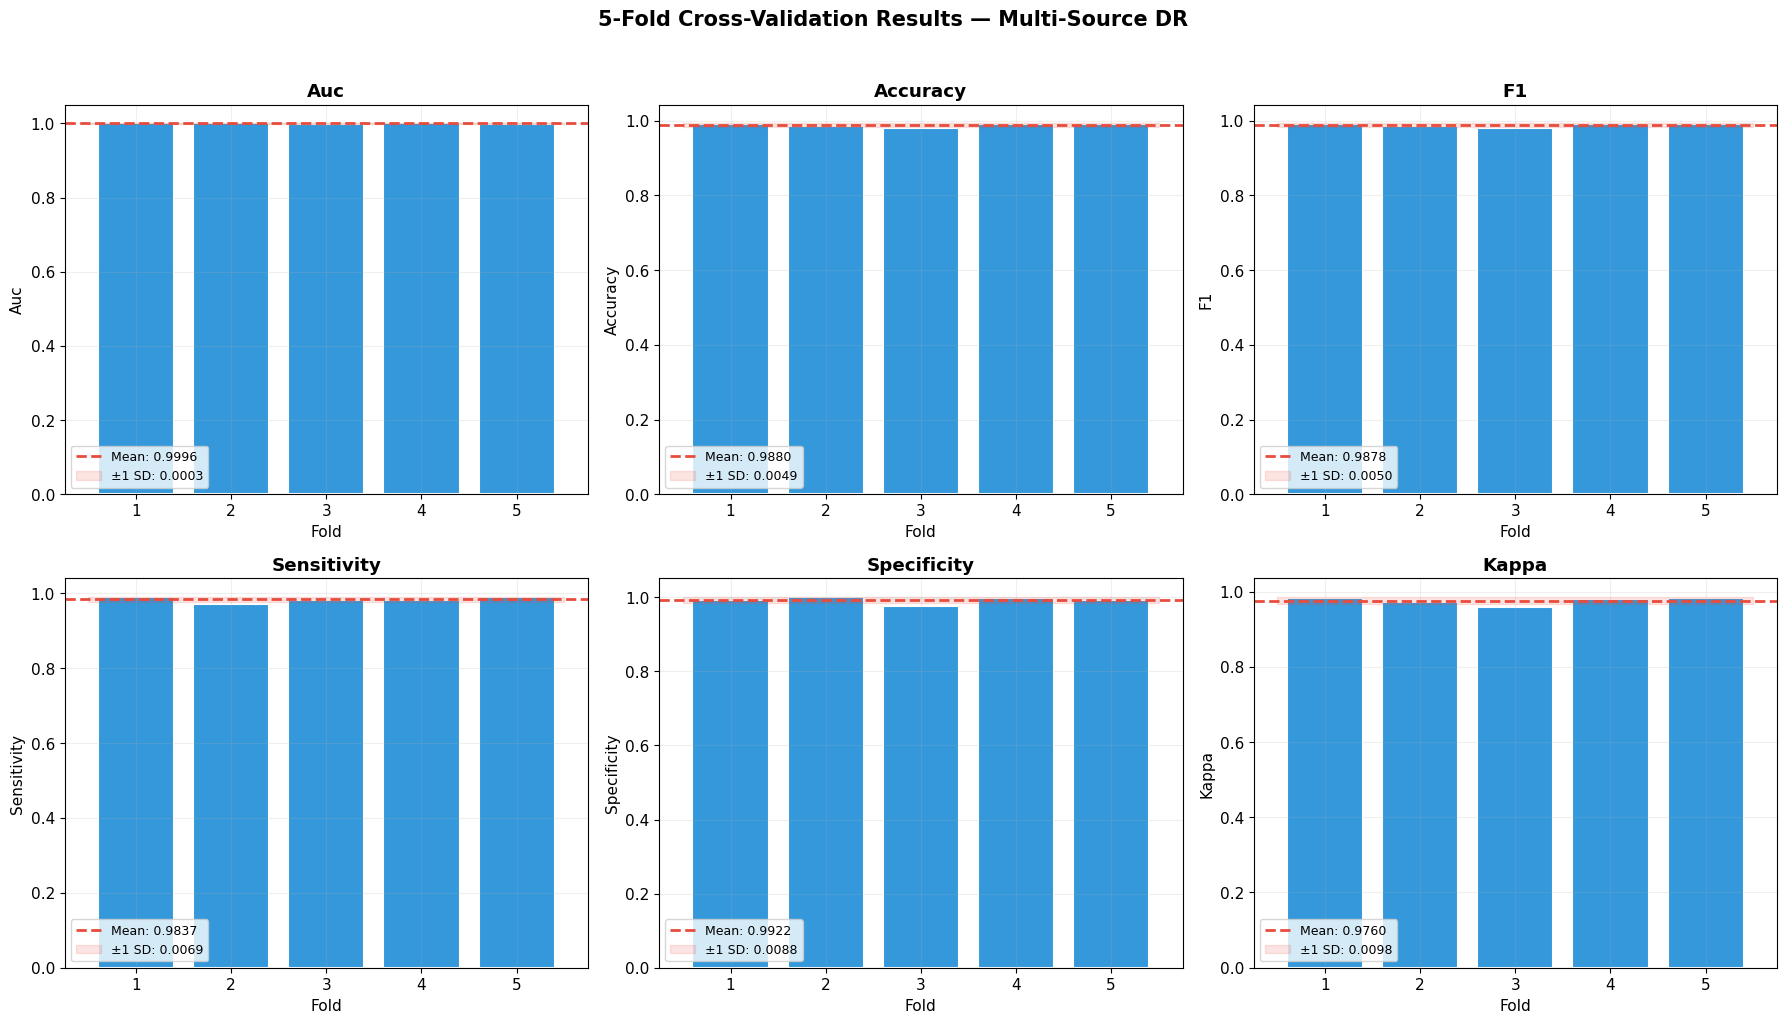

Saved → models/kfold/kfold_results.png


In [31]:
# ==================== VISUALIZATION ====================

metrics_to_plot = ['auc', 'accuracy', 'f1', 'sensitivity', 'specificity', 'kappa']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    vals = kfold_df[metric]
    bars = ax.bar(range(1, CFG.n_folds + 1), vals, color='#3498db',
                  edgecolor='white', linewidth=1.5)
    ax.axhline(y=vals.mean(), color='#e74c3c', linestyle='--', linewidth=2,
               label=f'Mean: {vals.mean():.4f}')
    ax.fill_between([0.5, CFG.n_folds + 0.5],
                    vals.mean() - vals.std(), vals.mean() + vals.std(),
                    alpha=0.15, color='#e74c3c', label=f'±1 SD: {vals.std():.4f}')
    ax.set_xlabel('Fold')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.set_title(metric.replace('_', ' ').title(), fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    ax.set_xticks(range(1, CFG.n_folds + 1))

plt.suptitle(f'{CFG.n_folds}-Fold Cross-Validation Results — Multi-Source DR',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CFG.output_dir, 'kfold_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {CFG.output_dir}/kfold_results.png')

---
## 4. K-Fold Ensemble Evaluation on Test Set

Load all 5 fold models, run TTA on the held-out test set, and compare:
- Individual fold performance on test set
- Soft ensemble (averaged predictions)

In [33]:
# ==================== ENSEMBLE TEST SET EVALUATION ====================

test_labels = test_df[CFG.label_column].values
all_fold_test_probs = []
fold_test_results = []

print(f'Test set: {len(test_df)} samples (DR ratio: {test_df[CFG.label_column].mean():.3f})')
print(f'\nLoading all {CFG.n_folds} fold models for ensemble evaluation...\n')

for fold_idx in range(CFG.n_folds):
    model_path = os.path.join(CFG.output_dir, f'best_{CFG.model_name}_fold{fold_idx+1}.pth')
    print(f'Fold {fold_idx+1}: {model_path}')

    # Load model
    ckpt = torch.load(model_path, map_location=device, weights_only=False)
    fold_model = DRBinaryModel(model_name=CFG.model_name, pretrained=False).to(device)
    fold_model.load_state_dict(ckpt['state_dict'])

    # TTA prediction on test set
    fold_probs = predict_tta(fold_model, test_df)
    all_fold_test_probs.append(fold_probs)

    # Per-fold test metrics
    fold_preds = (fold_probs >= 0.5).astype(int)
    fold_auc = roc_auc_score(test_labels, fold_probs)
    fold_f1  = f1_score(test_labels, fold_preds)
    fold_acc = accuracy_score(test_labels, fold_preds)
    fold_test_results.append({
        'model': f'Fold {fold_idx+1}',
        'auc': fold_auc, 'accuracy': fold_acc, 'f1': fold_f1,
        'sensitivity': recall_score(test_labels, fold_preds),
        'specificity': recall_score(test_labels, fold_preds, pos_label=0),
        'kappa': cohen_kappa_score(test_labels, fold_preds),
        'mcc': matthews_corrcoef(test_labels, fold_preds),
    })
    print(f'  Test AUC: {fold_auc:.4f} | F1: {fold_f1:.4f} | Acc: {fold_acc:.4f}')

    del fold_model
    if device.type == 'mps':
        torch.mps.empty_cache()
    elif device.type == 'cuda':
        torch.cuda.empty_cache()

# Soft ensemble
ensemble_probs = np.mean(all_fold_test_probs, axis=0)
ensemble_preds = (ensemble_probs >= 0.5).astype(int)

ens_metrics = {
    'model': 'Ensemble (5-fold)',
    'auc': roc_auc_score(test_labels, ensemble_probs),
    'accuracy': accuracy_score(test_labels, ensemble_preds),
    'f1': f1_score(test_labels, ensemble_preds),
    'sensitivity': recall_score(test_labels, ensemble_preds),
    'specificity': recall_score(test_labels, ensemble_preds, pos_label=0),
    'kappa': cohen_kappa_score(test_labels, ensemble_preds),
    'mcc': matthews_corrcoef(test_labels, ensemble_preds),
}
fold_test_results.append(ens_metrics)

# Summary table
test_comp_df = pd.DataFrame(fold_test_results)
print('\n' + '=' * 80)
print('  TEST SET EVALUATION: Individual Folds vs Ensemble')
print('=' * 80)
print(test_comp_df.to_string(index=False, float_format='{:.4f}'.format))
print('=' * 80)

# Save
test_comp_df.to_csv(os.path.join(CFG.output_dir, 'test_ensemble_comparison.csv'), index=False)

# Save ensemble predictions
pred_df = test_df[['image_id', CFG.label_column]].copy()
pred_df['ensemble_prob'] = ensemble_probs
pred_df['ensemble_pred'] = ensemble_preds
pred_df.to_csv(os.path.join(CFG.output_dir, 'test_ensemble_predictions.csv'), index=False)
print(f'\nSaved → {CFG.output_dir}/test_ensemble_comparison.csv')
print(f'Saved → {CFG.output_dir}/test_ensemble_predictions.csv')

Test set: 531 samples (DR ratio: 0.492)

Loading all 5 fold models for ensemble evaluation...

Fold 1: models/kfold/best_efficientnet_b3_fold1.pth
  Test AUC: 0.9977 | F1: 0.9885 | Acc: 0.9887
Fold 2: models/kfold/best_efficientnet_b3_fold2.pth
  Test AUC: 0.9971 | F1: 0.9846 | Acc: 0.9849
Fold 3: models/kfold/best_efficientnet_b3_fold3.pth
  Test AUC: 0.9994 | F1: 0.9846 | Acc: 0.9849
Fold 4: models/kfold/best_efficientnet_b3_fold4.pth
  Test AUC: 0.9987 | F1: 0.9847 | Acc: 0.9849
Fold 5: models/kfold/best_efficientnet_b3_fold5.pth
  Test AUC: 0.9979 | F1: 0.9827 | Acc: 0.9831

  TEST SET EVALUATION: Individual Folds vs Ensemble
            model    auc  accuracy     f1  sensitivity  specificity  kappa    mcc
           Fold 1 0.9977    0.9887 0.9885       0.9885       0.9889 0.9774 0.9774
           Fold 2 0.9971    0.9849 0.9846       0.9808       0.9889 0.9699 0.9699
           Fold 3 0.9994    0.9849 0.9846       0.9770       0.9926 0.9699 0.9700
           Fold 4 0.9987    0.9849

---
## K-Fold Cross-Validation Complete!

**Results saved to `models/kfold/`:**

| File | Description |
|------|-------------|
| `best_efficientnet_b3_fold{1-5}.pth` | Best model per fold |
| `kfold_results.csv` | Per-fold validation metrics |
| `kfold_results.png` | Metrics visualization |
| `test_ensemble_comparison.csv` | Fold vs ensemble on test set |
| `test_ensemble_predictions.csv` | Ensemble predictions on test set |